In [2]:
import pandas as pd

# Load dataset
df = pd.read_csv('dataset/Tweets.csv')  # change name if different

# View first few rows
df.head()


,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


In [3]:
# Dataset info
df.info()

# Check for missing values
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14640 entries, 0 to 14639
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   tweet_id                      14640 non-null  int64  
 1   airline_sentiment             14640 non-null  object 
 2   airline_sentiment_confidence  14640 non-null  float64
 3   negativereason                9178 non-null   object 
 4   negativereason_confidence     10522 non-null  float64
 5   airline                       14640 non-null  object 
 6   airline_sentiment_gold        40 non-null     object 
 7   name                          14640 non-null  object 
 8   negativereason_gold           32 non-null     object 
 9   retweet_count                 14640 non-null  int64  
 10  text                          14640 non-null  object 
 11  tweet_coord                   1019 non-null   object 
 12  tweet_created                 14640 non-null  object 
 13  t

tweet_id                            0
airline_sentiment                   0
airline_sentiment_confidence        0
negativereason                   5462
negativereason_confidence        4118
airline                             0
airline_sentiment_gold          14600
name                                0
negativereason_gold             14608
retweet_count                       0
text                                0
tweet_coord                     13621
tweet_created                       0
tweet_location                   4733
user_timezone                    4820
dtype: int64

In [4]:
df = df[['text', 'airline_sentiment']]  # Rename or adjust to match your dataset
df.rename(columns={'text': 'tweet', 'airline_sentiment': 'label'}, inplace=True)
df.head()


,tweet,label
0,@VirginAmerica What @dhepburn said.,neutral
1,@VirginAmerica plus you've added commercials t...,positive
2,@VirginAmerica I didn't today... Must mean I n...,neutral
3,@VirginAmerica it's really aggressive to blast...,negative
4,@VirginAmerica and it's a really big bad thing...,negative


In [5]:
import re

def clean_text(text):
    text = re.sub(r"http\S+|www\S+|https\S+", '', text, flags=re.MULTILINE)
    text = re.sub(r'\@w+|\#','', text)
    text = re.sub(r'[^\w\s]', '', text)
    text = text.lower()
    return text

df['cleaned_tweet'] = df['tweet'].apply(clean_text)
df.head()


,tweet,label,cleaned_tweet
0,@VirginAmerica What @dhepburn said.,neutral,virginamerica what dhepburn said
1,@VirginAmerica plus you've added commercials t...,positive,virginamerica plus youve added commercials to ...
2,@VirginAmerica I didn't today... Must mean I n...,neutral,virginamerica i didnt today must mean i need t...
3,@VirginAmerica it's really aggressive to blast...,negative,virginamerica its really aggressive to blast o...
4,@VirginAmerica and it's a really big bad thing...,negative,virginamerica and its a really big bad thing a...


In [6]:
from textblob import TextBlob

# Get sentiment polarity
df['polarity'] = df['cleaned_tweet'].apply(lambda x: TextBlob(x).sentiment.polarity)

# Classify polarity
def get_sentiment(p):
    if p > 0:
        return 'positive'
    elif p == 0:
        return 'neutral'
    else:
        return 'negative'

df['sentiment'] = df['polarity'].apply(get_sentiment)
df.head()


,tweet,label,cleaned_tweet,polarity,sentiment
0,@VirginAmerica What @dhepburn said.,neutral,virginamerica what dhepburn said,0.00000,neutral
1,@VirginAmerica plus you've added commercials t...,positive,virginamerica plus youve added commercials to ...,0.00000,neutral
2,@VirginAmerica I didn't today... Must mean I n...,neutral,virginamerica i didnt today must mean i need t...,-0.31250,negative
3,@VirginAmerica it's really aggressive to blast...,negative,virginamerica its really aggressive to blast o...,0.00625,positive
4,@VirginAmerica and it's a really big bad thing...,negative,virginamerica and its a really big bad thing a...,-0.35000,negative


In [7]:
df.to_csv('results/cleaned_sentiment_data.csv', index=False)


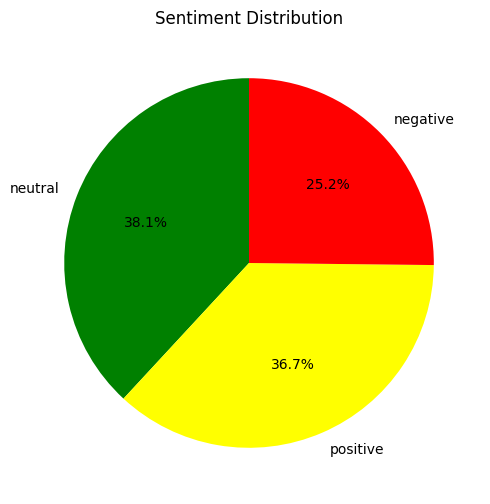

In [8]:
import matplotlib.pyplot as plt

sentiment_counts = df['sentiment'].value_counts()

# Pie chart
plt.figure(figsize=(6,6))
plt.pie(sentiment_counts, labels=sentiment_counts.index, autopct='%1.1f%%', startangle=90, colors=['green', 'yellow', 'red'])
plt.title('Sentiment Distribution')
plt.savefig('visuals/sentiment_pie_chart.png')  # Save image
plt.show()


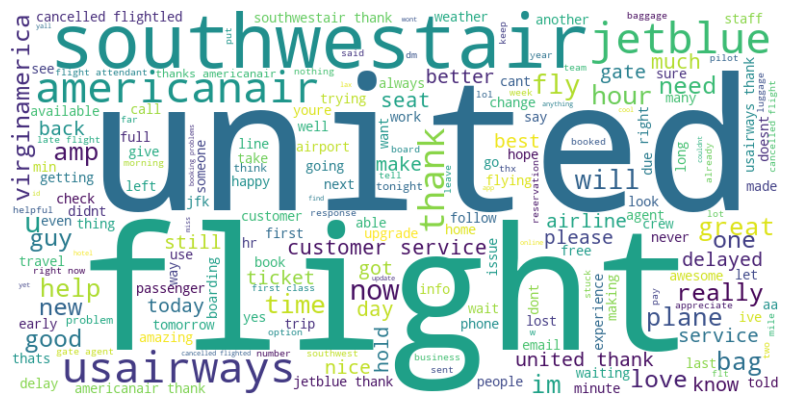

In [9]:
from wordcloud import WordCloud

positive_text = ' '.join(df[df['sentiment'] == 'positive']['cleaned_tweet'])

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(positive_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.savefig('visuals/positive_wordcloud.png')  # Save image
plt.show()


<Figure size 1200x600 with 0 Axes>

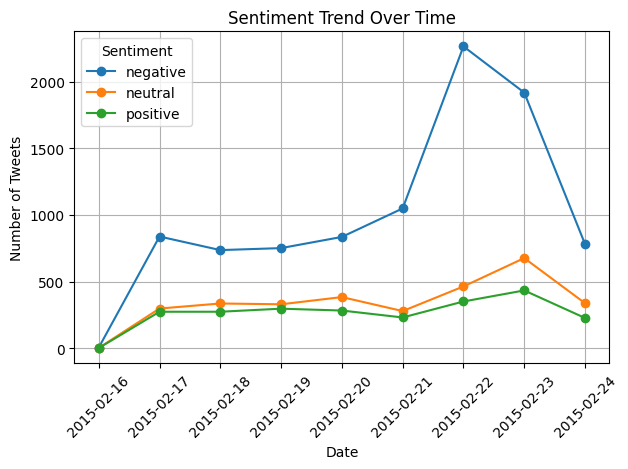

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv("dataset/Tweets.csv")

# Convert 'tweet_created' to datetime (in your dataset it's called tweet_created)
df['tweet_created'] = pd.to_datetime(df['tweet_created'])

# Group by date and sentiment
sentiment_trend = df.groupby([df['tweet_created'].dt.date, 'airline_sentiment']).size().unstack(fill_value=0)

# Plot the sentiment trend
plt.figure(figsize=(12, 6))
sentiment_trend.plot(kind='line', marker='o')
plt.title("Sentiment Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Tweets")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.legend(title="Sentiment")
plt.savefig("visuals/sentiment_trend_over_time.png")  # Save the figure
plt.show()


<Figure size 1200x600 with 0 Axes>

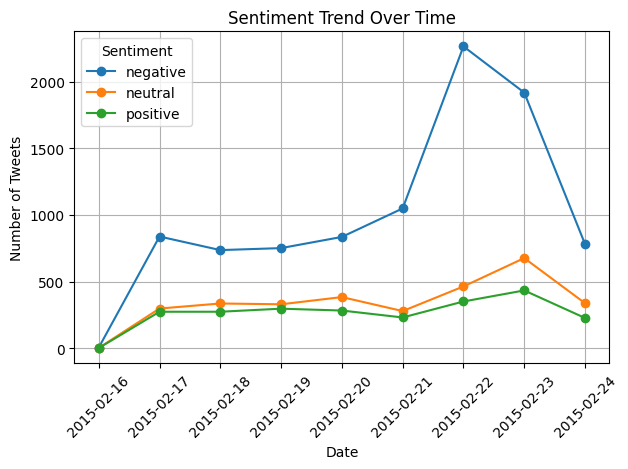

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv("dataset/Tweets.csv")

# Convert the correct column to datetime
df['tweet_created'] = pd.to_datetime(df['tweet_created'])

# Group by date and sentiment
sentiment_trend = df.groupby([df['tweet_created'].dt.date, 'airline_sentiment']).size().unstack(fill_value=0)

# Plot
plt.figure(figsize=(12, 6))
sentiment_trend.plot(kind='line', marker='o')
plt.title("Sentiment Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Tweets")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.legend(title="Sentiment")
plt.savefig("visuals/sentiment_trend_over_time.png")
plt.show()


<Figure size 1200x600 with 0 Axes>

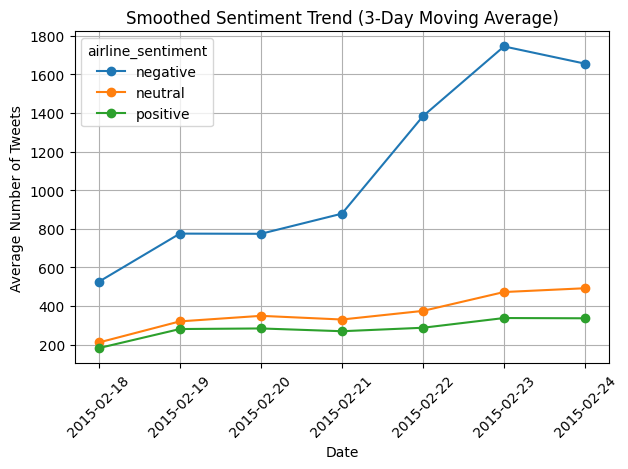

In [16]:
import matplotlib.pyplot as plt

# Calculate 3-day moving average
sentiment_moving_avg = sentiment_trend.rolling(window=3).mean()

# Plot the smoothed sentiment trend
plt.figure(figsize=(12, 6))
sentiment_moving_avg.plot(marker='o')
plt.title("Smoothed Sentiment Trend (3-Day Moving Average)")
plt.xlabel("Date")
plt.ylabel("Average Number of Tweets")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


In [17]:
plt.savefig("visuals/smoothed_sentiment_trend.png")


<Figure size 640x480 with 0 Axes>

In [19]:
print(df.columns)


Index(['tweet_id', 'airline_sentiment', 'airline_sentiment_confidence',
       'negativereason', 'negativereason_confidence', 'airline',
       'airline_sentiment_gold', 'name', 'negativereason_gold',
       'retweet_count', 'text', 'tweet_coord', 'tweet_created',
       'tweet_location', 'user_timezone'],
      dtype='object')


In [20]:
from textblob import TextBlob

# Create a new column for sentiment
def get_sentiment(text):
    blob = TextBlob(text)
    polarity = blob.sentiment.polarity
    if polarity > 0:
        return 'positive'
    elif polarity < 0:
        return 'negative'
    else:
        return 'neutral'

df['sentiment'] = df['text'].apply(get_sentiment)


In [21]:
from collections import Counter
import re
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+|https\S+", '', text, flags=re.MULTILINE)
    text = re.sub(r'\W', ' ', text)
    words = text.split()
    words = [word for word in words if word not in stop_words and len(word) > 2]
    return words

sentiment_words = {}

for sentiment in df['sentiment'].unique():
    all_words = []
    subset = df[df['sentiment'] == sentiment]
    for tweet in subset['text']:
        all_words.extend(clean_text(tweet))
    word_freq = Counter(all_words).most_common(10)
    sentiment_words[sentiment] = word_freq

for sentiment, words in sentiment_words.items():
    print(f"\nTop words for {sentiment.upper()} sentiment:")
    for word, count in words:
        print(f"{word}: {count}")



Top words for NEUTRAL sentiment:
united: 1476
flight: 1425
americanair: 1139
usairways: 1132
southwestair: 936
jetblue: 907
get: 543
cancelled: 471
help: 405
hold: 311

Top words for NEGATIVE sentiment:
flight: 1231
united: 1199
usairways: 950
americanair: 774
southwestair: 507
jetblue: 434
service: 406
late: 344
get: 340
cancelled: 313

Top words for POSITIVE sentiment:
united: 1489
flight: 1283
jetblue: 1054
americanair: 1051
southwestair: 1018
usairways: 971
thanks: 960
get: 457
service: 347
time: 329


[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/saiharshavardhan/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [22]:
from collections import Counter
import re
import nltk
from nltk.corpus import stopwords

# Download stopwords (run once)
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

# Function to clean and tokenize
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+|https\S+", '', text, flags=re.MULTILINE)  # Remove links
    text = re.sub(r'\W', ' ', text)  # Remove non-word characters
    words = text.split()
    words = [word for word in words if word not in stop_words and len(word) > 2]
    return words

# Get most common words for each sentiment
sentiment_words = {}

for sentiment in df['sentiment'].unique():
    all_words = []
    subset = df[df['sentiment'] == sentiment]
    for tweet in subset['text']:
        all_words.extend(clean_text(tweet))
    word_freq = Counter(all_words).most_common(10)
    sentiment_words[sentiment] = word_freq

# Display
for sentiment, words in sentiment_words.items():
    print(f"\nTop words for {sentiment.upper()} sentiment:")
    for word, count in words:
        print(f"{word}: {count}")



Top words for NEUTRAL sentiment:
united: 1476
flight: 1425
americanair: 1139
usairways: 1132
southwestair: 936
jetblue: 907
get: 543
cancelled: 471
help: 405
hold: 311

Top words for NEGATIVE sentiment:
flight: 1231
united: 1199
usairways: 950
americanair: 774
southwestair: 507
jetblue: 434
service: 406
late: 344
get: 340
cancelled: 313

Top words for POSITIVE sentiment:
united: 1489
flight: 1283
jetblue: 1054
americanair: 1051
southwestair: 1018
usairways: 971
thanks: 960
get: 457
service: 347
time: 329


[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/saiharshavardhan/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [26]:
import os

# Create the 'outputs' directory if it doesn't exist
if not os.path.exists('outputs'):
    os.makedirs('outputs')

# Now save the DataFrame to CSV
sentiment_trend.to_csv("outputs/sentiment_trend.csv")


In [27]:
sentiment_moving_avg.to_csv("outputs/sentiment_3day_avg.csv")


In [28]:
import csv

with open("outputs/top_words_by_sentiment.csv", "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["Sentiment", "Word", "Frequency"])
    
    for sentiment, words in sentiment_words.items():
        for word, freq in words:
            writer.writerow([sentiment, word, freq])


In [1]:
pip install reportlab


Note: you may need to restart the kernel to use updated packages.


In [7]:
from reportlab.lib.pagesizes import letter
from reportlab.lib import colors
from reportlab.pdfgen import canvas
import matplotlib.pyplot as plt
import pandas as pd
from io import BytesIO


In [6]:
def generate_pdf(sentiment_trend, sentiment_smooth):
    # Create a canvas object to generate PDF
    pdf_filename = "sentiment_analysis_report.pdf"
    c = canvas.Canvas(pdf_filename, pagesize=letter)
    width, height = letter  # Get the size of the page

    # Title of the report
    c.setFont("Helvetica-Bold", 18)
    c.drawString(30, height - 50, "Sentiment Analysis Report")

    # Sentiment analysis summary
    c.setFont("Helvetica", 12)
    c.drawString(30, height - 80, "Sentiment Analysis Summary:")
    c.drawString(30, height - 100, f"Total number of tweets analyzed: {len(df)}")
    c.drawString(30, height - 120, f"Positive Sentiment: {df['sentiment'].value_counts().get('positive', 0)}")
    c.drawString(30, height - 140, f"Negative Sentiment: {df['sentiment'].value_counts().get('negative', 0)}")
    c.drawString(30, height - 160, f"Neutral Sentiment: {df['sentiment'].value_counts().get('neutral', 0)}")

    # Save sentiment trend plot as an image and add to the PDF
    plt.figure(figsize=(12, 6))
    sentiment_trend.plot(kind='line', marker='o')
    plt.title("Sentiment Trend Over Time")
    plt.xlabel("Date")
    plt.ylabel("Number of Tweets")
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.tight_layout()

    img_buffer = BytesIO()
    plt.savefig(img_buffer, format='png')
    img_buffer.seek(0)
    c.drawImage(img_buffer, 30, height - 350, width=500, height=300)

    # Save smoothed sentiment plot as an image and add to the PDF
    plt.figure(figsize=(12, 6))
    sentiment_smooth.plot(kind='line')
    plt.title("Smoothed Sentiment Trend (3-Day Moving Average)")
    plt.xlabel("Date")
    plt.ylabel("Average Number of Tweets")
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.tight_layout()

    img_buffer = BytesIO()
    plt.savefig(img_buffer, format='png')
    img_buffer.seek(0)
    c.drawImage(img_buffer, 30, height - 700, width=500, height=300)

    # Finalize and save the PDF
    c.showPage()
    c.save()

    print(f"PDF Report saved as {pdf_filename}")


In [27]:
import os

# Create necessary folders if they don't exist
os.makedirs("dataset", exist_ok=True)
os.makedirs("outputs", exist_ok=True)


In [28]:
import pandas as pd

# Sample data
data = {
    "created_at": pd.date_range(start="2024-01-01", periods=10, freq='D'),
    "text": [
        "I love this product!", "Worst experience ever.", "Not bad at all.",
        "Totally awesome!", "I hate this.", "So-so service.", 
        "Amazing deal today!", "Disappointed with the quality.", "It's okay.", "Best day ever!"
    ],
    "sentiment": ["positive", "negative", "neutral", "positive", "negative", "neutral", 
                  "positive", "negative", "neutral", "positive"]
}

df = pd.DataFrame(data)

# Save it for future use
df.to_csv("dataset/your_sentiment_data.csv", index=False)


In [29]:
df = pd.read_csv("dataset/your_sentiment_data.csv")
df['created_at'] = pd.to_datetime(df['created_at'])  # Ensure datetime format
df.head()


,created_at,text,sentiment
0,2024-01-01,I love this product!,positive
1,2024-01-02,Worst experience ever.,negative
2,2024-01-03,Not bad at all.,neutral
3,2024-01-04,Totally awesome!,positive
4,2024-01-05,I hate this.,negative


In [30]:
sentiment_trend = df.groupby([df['created_at'].dt.date, 'sentiment']).size().unstack(fill_value=0)
sentiment_trend.head()


sentiment,negative,neutral,positive
created_at,,,
2024-01-01,0,0,1
2024-01-02,1,0,0
2024-01-03,0,1,0
2024-01-04,0,0,1
2024-01-05,1,0,0


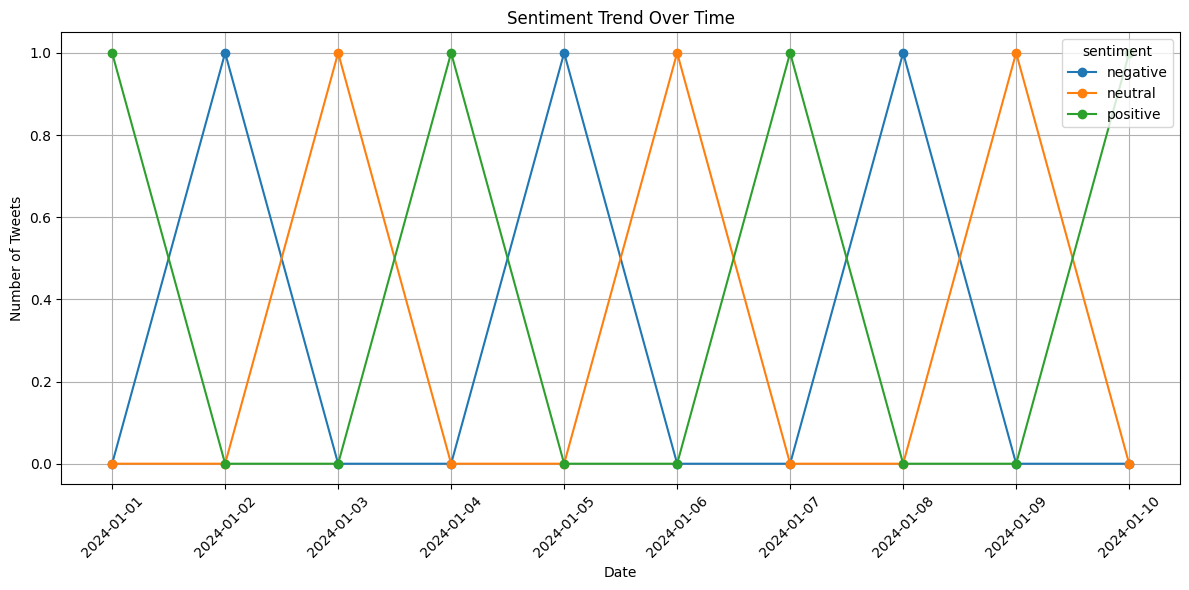

In [31]:
import matplotlib.pyplot as plt

sentiment_trend.plot(kind='line', figsize=(12, 6), marker='o')
plt.title("Sentiment Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Tweets")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


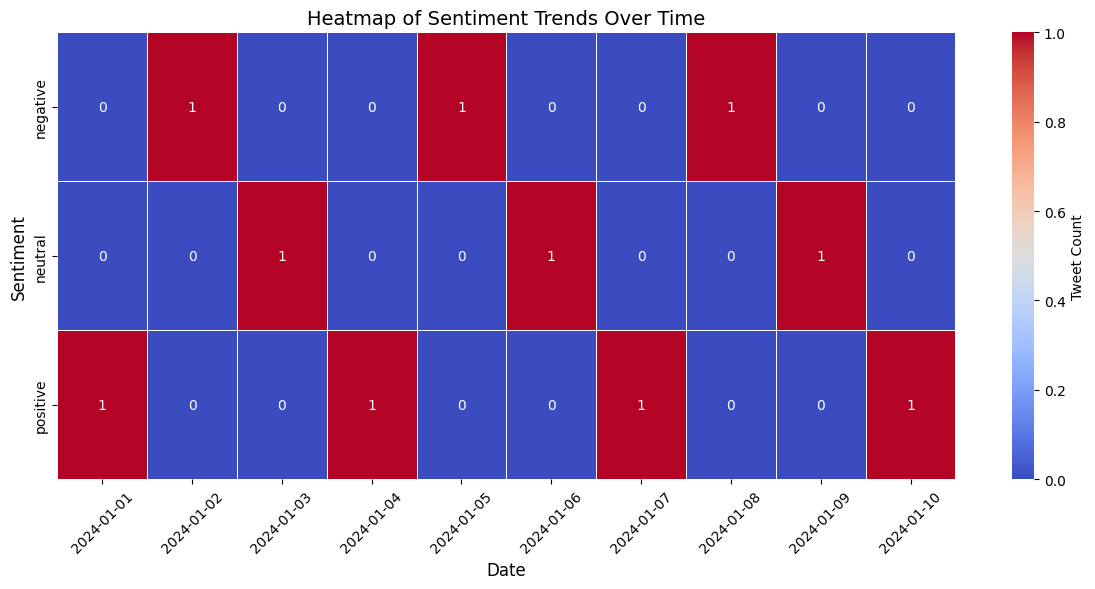

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot the sentiment heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(
    sentiment_trend.T,               # Transposed for sentiment on y-axis
    annot=True,                      # Show numbers in cells
    fmt='d',                         # Integer formatting
    cmap='coolwarm',                 # Color map
    linewidths=0.5,                  # Cell borders
    cbar_kws={'label': 'Tweet Count'}  # Color bar label
)

plt.title("Heatmap of Sentiment Trends Over Time", fontsize=14)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Sentiment", fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [33]:
pip install fpdf2 pillow


Note: you may need to restart the kernel to use updated packages.


In [35]:
df['created_at'] = pd.to_datetime(df['created_at'])
sentiment_trend = df.groupby([df['created_at'].dt.date, 'sentiment']).size().unstack(fill_value=0)


In [36]:
sentiment_smooth = sentiment_trend.rolling(window=3).mean()


In [37]:
fig1 = sentiment_trend.plot(marker='o', figsize=(10, 5), title="Sentiment Trend Over Time")
save_plot(fig1.get_figure(), "outputs/sentiment_trend.png")
plt.clf()

fig2 = sentiment_smooth.plot(figsize=(10, 5), title="Smoothed Sentiment Trend (3-Day MA)")
save_plot(fig2.get_figure(), "outputs/sentiment_smooth.png")
plt.clf()


<Figure size 1000x500 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

In [38]:
from fpdf import FPDF
from PIL import Image
import os

# Function to save plot images
def save_plot(fig, filename):
    fig.savefig(filename, bbox_inches='tight')

# Save your plots first
fig1 = sentiment_trend.plot(marker='o', figsize=(10, 5), title="Sentiment Trend Over Time")
save_plot(fig1.get_figure(), "outputs/sentiment_trend.png")
plt.clf()

fig2 = sentiment_smooth.plot(figsize=(10, 5), title="Smoothed Sentiment Trend (3-Day MA)")
save_plot(fig2.get_figure(), "outputs/sentiment_smooth.png")
plt.clf()

plt.figure(figsize=(12, 6))
sns.heatmap(sentiment_trend.T, annot=True, cmap='coolwarm', fmt='d', cbar_kws={'label': 'Tweet Count'})
plt.title("Sentiment Heatmap Over Time")
plt.tight_layout()
plt.savefig("outputs/sentiment_heatmap.png")
plt.clf()

# Generate PDF
pdf = FPDF()
pdf.set_auto_page_break(auto=True, margin=15)

# First Page
pdf.add_page()
pdf.set_font("Arial", "B", 16)
pdf.cell(0, 10, "Social Media Sentiment Analysis Report", ln=True, align="C")

# Add Description
pdf.set_font("Arial", "", 12)
pdf.ln(10)
pdf.multi_cell(0, 10, """
This report analyzes public sentiment from social media posts using Natural Language Processing (NLP).
It includes visualizations of sentiment trends over time, smoothed moving averages, and a heatmap for deeper insights.
""")

# Add plots
for image in ["sentiment_trend.png", "sentiment_smooth.png", "sentiment_heatmap.png"]:
    path = f"outputs/{image}"
    if os.path.exists(path):
        pdf.add_page()
        pdf.set_font("Arial", "B", 14)
        pdf.cell(0, 10, image.replace("_", " ").replace(".png", "").title(), ln=True)
        pdf.image(path, w=180)

# Save PDF
pdf.output("outputs/Sentiment_Analysis_Report.pdf")


/var/folders/jc/fyqm1cds6gg81w6_ng8_28_w0000gn/T/ipykernel_7012/1027690330.py:31: DeprecationWarning: Substituting font arial by core font helvetica - This is deprecated since v2.7.8, and will soon be removed
  pdf.set_font("Arial", "B", 16)
/var/folders/jc/fyqm1cds6gg81w6_ng8_28_w0000gn/T/ipykernel_7012/1027690330.py:32: DeprecationWarning: The parameter "ln" is deprecated since v2.5.2. Instead of ln=True use new_x=XPos.LMARGIN, new_y=YPos.NEXT.
  pdf.cell(0, 10, "Social Media Sentiment Analysis Report", ln=True, align="C")
/var/folders/jc/fyqm1cds6gg81w6_ng8_28_w0000gn/T/ipykernel_7012/1027690330.py:35: DeprecationWarning: Substituting font arial by core font helvetica - This is deprecated since v2.7.8, and will soon be removed
  pdf.set_font("Arial", "", 12)
/var/folders/jc/fyqm1cds6gg81w6_ng8_28_w0000gn/T/ipykernel_7012/1027690330.py:47: DeprecationWarning: Substituting font arial by core font helvetica - This is deprecated since v2.7.8, and will soon be removed
  pdf.set_font("Ari

<Figure size 1000x500 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

<Figure size 1200x600 with 0 Axes>